In [8]:
import sounddevice as sd
from scipy.io.wavfile import write

sample_rate = 16000  # better for speech
duration = 10
filename = "output.wav"

print("Recording...")
recording = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
sd.wait()

write(filename, sample_rate, recording)
print("Saved to output.wav")

Recording...
Saved to output.wav


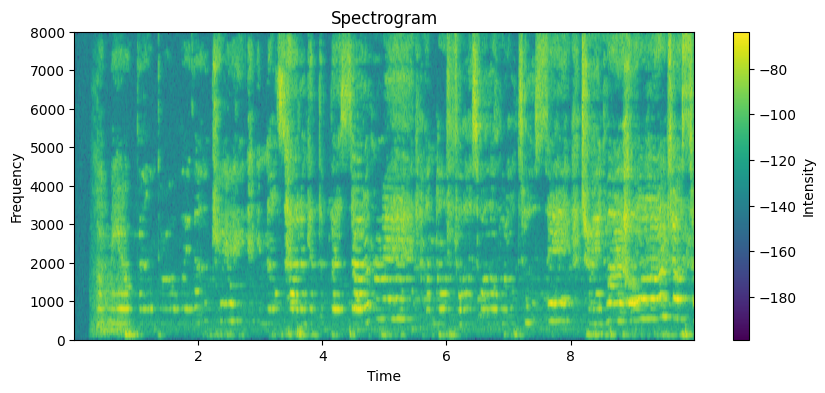

In [9]:
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load audio
sample_rate, signal = wavfile.read("output.wav")

# If stereo → convert to mono (safety)
if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Create spectrogram
plt.figure(figsize=(10, 4))
plt.specgram(signal, Fs=sample_rate)

plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="Intensity")

plt.show()

In [12]:
from scipy.io import wavfile
from scipy.signal import stft

# Load audio
sample_rate, signal = wavfile.read("output.wav")

# Convert to mono if needed
if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Compute STFT
f, t, Zxx = stft(signal, fs=sample_rate, nperseg=1024)

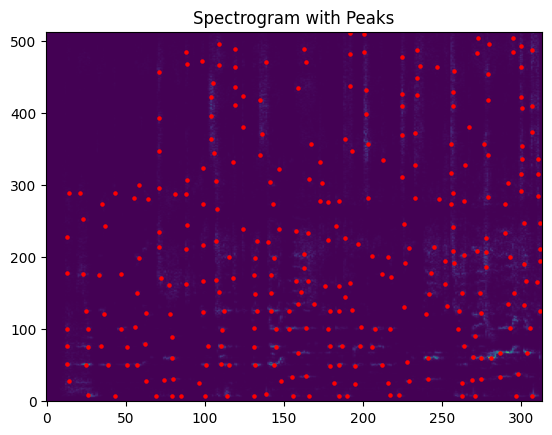

In [13]:
import numpy as np

spec = np.abs(Zxx)          # from STFT
log_spec = np.log1p(spec)   # stabilize scale

from scipy.ndimage import maximum_filter

neighborhood_size = (30, 10)  # (freq, time)
local_max = maximum_filter(log_spec, size=neighborhood_size) == log_spec

threshold = np.mean(log_spec) + 0.5 * np.std(log_spec)

detected_peaks = local_max & (log_spec > threshold)

freq_idx, time_idx = np.where(detected_peaks)

peaks = list(zip(freq_idx, time_idx))

#neighborhood_size = (30, 10)  # better than square
max_peaks = 500
if len(peaks) > max_peaks:
    peaks = peaks[:max_peaks]

peak_values = log_spec[freq_idx, time_idx]
peaks = sorted(zip(freq_idx, time_idx, peak_values), key=lambda x: -x[2])

import matplotlib.pyplot as plt

plt.imshow(log_spec, aspect='auto', origin='lower')
plt.scatter(time_idx, freq_idx, color='red', s=5)
plt.title("Spectrogram with Peaks")
plt.show()



In [ ]:
FAN_OUT = 5        # number of pairs per anchor
MAX_TIME_DELTA = 50  # frames to look ahead

hashes = []

for i in range(len(peaks)):
    f1, t1 = peaks[i]

    for j in range(1, FAN_OUT + 1):
        if i + j < len(peaks):
            f2, t2 = peaks[i + j]

            delta_t = t2 - t1

            if 0 < delta_t <= MAX_TIME_DELTA:
                hash_value = (f1, f2, delta_t)

                # Store with anchor time (important for matching)
                hashes.append((hash_value, t1))

